# Лабораторная 8. Автоэнкодеры

**Задание.** Реализовать автоэнкодеры: а) автоэнкодер с полносвязными слоями;
б) вариационный автоэнкодер.

Для обеих моделей, используя выборки MNIST и FashionMNIST:

1) реализовать различные варианты зашумления и исследовать, как зависит качество
нормализации изображения (очистки от шума): а) от типа зашумления (равномерный
шум, нормальный шум, локальная порча изображений); б) от размерности пространства
скрытых признаков; в) от количества и ширины слоёв кодера и декодера; а также от
гиперпараметров: г) количества эпох; д) коэффициента обучения;

2) оценить качество изображений, восстановленных из чистых и зашумлённых
изображений;

3) оценить возможность генерирования новых изображений из случайных точек в
латентном пространстве (пространстве скрытых признаков).

## 1. Теория

### Данные

MNIST и FashionMNIST: изображения $28 \times 28$ в градациях серого, 10 классов.
Из обучающей части каждой выборки берутся 8000 изображений для обучения и 1000
отложенных для сравнения гиперпараметров, из тестовой части 1000 изображений для
итоговой оценки. Яркости делятся на 255, изображение разворачивается в вектор
длины 784.

### Автоэнкодер

Автоэнкодер состоит из кодера $f$ и декодера $g$ и обучается восстанавливать
собственный вход:

$$z = f(x), \qquad \hat x = g(z), \qquad L = \lVert x - \hat x\rVert^2 .$$

Размерность $z$ меньше размерности $x$, поэтому сеть вынуждена сжать изображение
до $d$ чисел так, чтобы по ним его можно было восстановить.

### Очистка от шума

Шумоподавляющий автоэнкодер обучается на парах «зашумлённое изображение на
входе, чистое на выходе»:

$$L = \lVert x - g(f(\tilde x))\rVert^2, \qquad \tilde x = \text{шум}(x).$$

Виды зашумления: равномерный шум (добавка $\mathrm{U}[-\ell, \ell]$ к каждому
пикселю), нормальный шум (добавка $\mathrm{N}(0, \ell^2)$), после добавки
значения обрезаются до $[0, 1]$; локальная порча: два квадратных пятна случайного
положения со стороной $28\ell$, но не меньше 4 пикселей, заполненные случайными
значениями.

### Вариационный автоэнкодер

Кодер выдаёт не точку, а параметры распределения $\mu(x)$ и $\log\sigma^2(x)$;
код берётся как $z = \mu + \sigma\varepsilon$ при
$\varepsilon \sim \mathcal{N}(0, I)$ (репараметризация, благодаря которой
градиент проходит через выборку). Функция потерь

$$L = \underbrace{\lVert x - \hat x\rVert^2}_{\text{восстановление}}
    + \beta\underbrace{\left(-\tfrac12\sum_{j}\bigl(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\bigr)\right)}_{\text{KL-дивергенция}} .$$

Второе слагаемое стягивает распределение кодов к $\mathcal{N}(0, I)$, поэтому
точка, взятая из $\mathcal{N}(0, I)$, декодируется в правдоподобное изображение.
Здесь $\beta = 1$. При оценке восстановления берётся $z = \mu$.

### Меры качества

$$\mathrm{MSE} = \frac{1}{n}\sum_k (x_k - \hat x_k)^2 .$$

SSIM (structural similarity) сравнивает локальные яркость, контраст и структуру
и лучше согласуется со зрительной оценкой; значение 1 означает совпадение.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| размерность латента | 2, 4, 8, 16, 32, 64 |
| тип шума | равномерный, нормальный, пятна |
| уровень шума | $0.2$, $0.4$ |
| слои кодера | $(128)$, $(256)$, $(512, 256)$, $(512, 256, 128)$ |
| число эпох | 10, 20, 40 |
| коэффициент обучения | $3\cdot10^{-4}$, $10^{-3}$, $3\cdot10^{-3}$ |

Перебор последовательный. Размерность латента выбирается при нормальном шуме
уровня 0.3, при ней сравниваются виды шума, затем подбираются слои кодера, число
эпох и коэффициент обучения. Выбор делается по MSE восстановления зашумлённых
отложенных изображений. Оптимизатор Adam, батч 128.

## 2. Данные и модели шума

In [1]:
import os
import struct
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity
from sklearn.decomposition import PCA

torch.manual_seed(20260905)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, устройство: {DEVICE}')

torch 2.11.0+cu128, устройство: cuda


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def find_dir(name, env):
    for c in [os.environ.get(env), f'../data/{name}/raw', f'data/{name}/raw',
              '../../bachelor/Perceptron/data_generation/MNIST/raw' if name == 'MNIST' else None]:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError(name)


def load(name, env, n_train, n_val, n_test, rng):
    """Обучающая и отложенная части из обучающей выборки, тестовая из тестовой."""
    D = find_dir(name, env)
    Xtr = read_idx(D / 'train-images-idx3-ubyte')
    Xte = read_idx(D / 't10k-images-idx3-ubyte')
    yte = read_idx(D / 't10k-labels-idx1-ubyte')
    perm = rng.permutation(len(Xtr))
    itr, ival = perm[:n_train], perm[n_train:n_train + n_val]  # части не пересекаются
    ite = rng.choice(len(Xte), n_test, replace=False)
    return (Xtr[itr].astype(np.float32) / 255.0, Xtr[ival].astype(np.float32) / 255.0,
            Xte[ite].astype(np.float32) / 255.0, yte[ite])


DATA = {
    'MNIST': load('MNIST', 'MNIST_DIR', 8000, 1000, 1000, np.random.default_rng(20260905)),
    'FashionMNIST': load('FashionMNIST', 'FASHION_DIR', 8000, 1000, 1000,
                         np.random.default_rng(20260905)),
}
for k, (a, b, c, _) in DATA.items():
    print(f'{k}: обучающая {a.shape}, отложенная {b.shape}, тестовая {c.shape}')

MNIST: обучающая (8000, 28, 28), отложенная (1000, 28, 28), тестовая (1000, 28, 28)
FashionMNIST: обучающая (8000, 28, 28), отложенная (1000, 28, 28), тестовая (1000, 28, 28)


In [3]:
def noise_uniform(X, level, rng):
    """Равномерный шум: добавка U[-level, level] к каждому пикселю."""
    return np.clip(X + rng.uniform(-level, level, X.shape), 0, 1).astype(np.float32)


def noise_normal(X, level, rng):
    """Нормальный шум с sigma = level."""
    return np.clip(X + rng.normal(0, level, X.shape), 0, 1).astype(np.float32)


def noise_blot(X, level, rng):
    """Локальная порча: квадратные пятна случайного положения."""
    X = X.copy()
    size = max(4, int(round(28 * level)))
    n_blots = 2
    for i in range(len(X)):
        for _ in range(n_blots):
            r0 = rng.integers(0, 28 - size + 1)
            c0 = rng.integers(0, 28 - size + 1)
            X[i, r0:r0 + size, c0:c0 + size] = rng.random((size, size))
    return X.astype(np.float32)


NOISES = {'равномерный': noise_uniform, 'нормальный': noise_normal,
          'пятна': noise_blot}

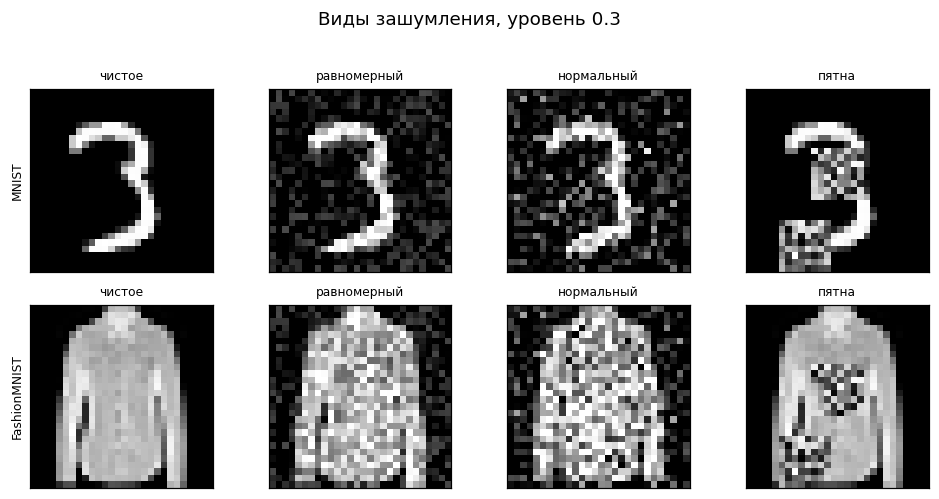

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(9, 4.4))
for row, ds in enumerate(['MNIST', 'FashionMNIST']):
    X = DATA[ds][1]
    axes[row, 0].imshow(X[0], cmap='gray'); axes[row, 0].set_title('чистое', fontsize=8)
    for col, (name, f) in enumerate(NOISES.items(), start=1):
        axes[row, col].imshow(f(X[:1], 0.3, np.random.default_rng(1))[0], cmap='gray')
        axes[row, col].set_title(name, fontsize=8)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(ds, fontsize=8)
fig.suptitle('Виды зашумления, уровень 0.3', y=1.02)
plt.tight_layout()
plt.show()

## 3. Автоэнкодер и вариационный автоэнкодер

In [5]:
def dense_stack(dims):
    """Полносвязные слои с ReLU между ними по размерам dims."""
    layers = []
    for a, b in zip(dims[:-1], dims[1:]):
        layers += [nn.Linear(a, b), nn.ReLU()]
    return layers


class AE(nn.Module):
    """Автоэнкодер с полносвязными слоями."""

    def __init__(self, latent=16, hidden=(256,)):
        super().__init__()
        self.latent = latent
        hidden = list(hidden)
        # кодер сужает 784 до latent, декодер разворачивает обратно теми же ширинами
        self.encoder = nn.Sequential(*dense_stack([784] + hidden),
                                     nn.Linear(hidden[-1], latent))
        self.decoder = nn.Sequential(*dense_stack([latent] + hidden[::-1]),
                                     nn.Linear(hidden[0], 784), nn.Sigmoid())

    def forward(self, x):
        return self.decoder(self.encoder(x)), None

    def sample(self, n):
        """Декодирование n случайных точек латентного пространства."""
        device = next(self.parameters()).device  # где лежат веса, там и считаем
        return self.decoder(torch.randn(n, self.latent, device=device))


class VAE(nn.Module):
    """Вариационный автоэнкодер."""

    def __init__(self, latent=16, hidden=(256,)):
        super().__init__()
        self.latent = latent
        hidden = list(hidden)
        self.encoder = nn.Sequential(*dense_stack([784] + hidden))
        self.mu = nn.Linear(hidden[-1], latent)          # среднее распределения кодов
        self.logvar = nn.Linear(hidden[-1], latent)      # логарифм дисперсии
        self.decoder = nn.Sequential(*dense_stack([latent] + hidden[::-1]),
                                     nn.Linear(hidden[0], 784), nn.Sigmoid())

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        if not self.training:  # при оценке код берётся равным среднему
            return self.decoder(mu), (mu, logvar)
        # репараметризация: z = mu + sigma * eps, случайность вынесена в eps
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decoder(z), (mu, logvar)

    def sample(self, n):
        device = next(self.parameters()).device
        return self.decoder(torch.randn(n, self.latent, device=device))

In [6]:
def train_ae(model, Xn, Xc, epochs, lr, batch=128, beta=1.0, seed=0):
    """Xn это вход (возможно зашумлённый), Xc это цель (чистое изображение)."""
    torch.manual_seed(seed)
    model.to(DEVICE)  # веса переносятся на видеокарту, если она есть
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    xn = torch.tensor(Xn.reshape(len(Xn), -1)).to(DEVICE)  # каждое изображение в строку
    xc = torch.tensor(Xc.reshape(len(Xc), -1)).to(DEVICE)
    for _ in range(epochs):
        perm = torch.randperm(len(xn), device=DEVICE)  # новый порядок объектов
        for s in range(0, len(xn), batch):
            b = perm[s:s + batch]
            out, extra = model(xn[b])
            loss = ((out - xc[b]) ** 2).sum(1).mean()  # квадрат нормы x - x_hat, среднее по батчу
            if extra is not None:  # у VAE добавляется KL-слагаемое
                mu, logvar = extra
                kl = -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(1).mean()
                loss = loss + beta * kl
            opt.zero_grad()  # обнуление градиентов прошлого шага
            loss.backward()  # градиенты функции потерь по весам
            opt.step()  # шаг оптимизатора


def reconstruct(model, X):
    """Прогон изображений через сеть и обратно в форму (N, 28, 28)."""
    model.eval()
    with torch.no_grad():  # при оценке градиенты не нужны
        out, _ = model(torch.tensor(X.reshape(len(X), -1)).to(DEVICE))
    return out.cpu().numpy().reshape(-1, 28, 28)  # .cpu() забирает результат с видеокарты


def quality(ref, rec):
    """MSE по пикселям и средний SSIM по изображениям."""
    mse = float(np.mean((ref - rec) ** 2))
    ssim = float(np.mean([structural_similarity(a, b, data_range=1.0)
                          for a, b in zip(ref, rec)]))
    return mse, ssim

## 4. Размерность латентного пространства

In [7]:
EPOCHS = 20
LEVEL = 0.3
Xtr, Xval, Xte, yte = DATA['MNIST']
Xtr_n = noise_normal(Xtr, LEVEL, np.random.default_rng(20260905))
Xval_n = noise_normal(Xval, LEVEL, np.random.default_rng(1))

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for latent in [2, 4, 8, 16, 32, 64]:
        torch.manual_seed(20260905)
        model = cls(latent=latent, hidden=(256,))
        train_ae(model, Xtr_n, Xtr, epochs=EPOCHS, lr=1e-3)
        mse_n, ssim_n = quality(Xval, reconstruct(model, Xval_n))
        mse_c, ssim_c = quality(Xval, reconstruct(model, Xval))
        rows.append(dict(stage='латент', dataset='MNIST', model=cls_name,
                         latent=latent, hidden='(256,)', noise='нормальный',
                         level=LEVEL, epochs=EPOCHS, lr=1e-3,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters())))
lat = pd.DataFrame(rows)
print(lat.pivot_table(index='latent', columns='model',
                      values=['mse_noisy', 'ssim_noisy']).round(4).to_string())

       mse_noisy         ssim_noisy        
model         AE     VAE         AE     VAE
latent                                     
2         0.0488  0.0494     0.4210  0.3973
4         0.0360  0.0382     0.5753  0.5208
8         0.0275  0.0292     0.6826  0.6082
16        0.0208  0.0279     0.7484  0.6109
32        0.0165  0.0290     0.7924  0.5905
64        0.0154  0.0304     0.8045  0.5560


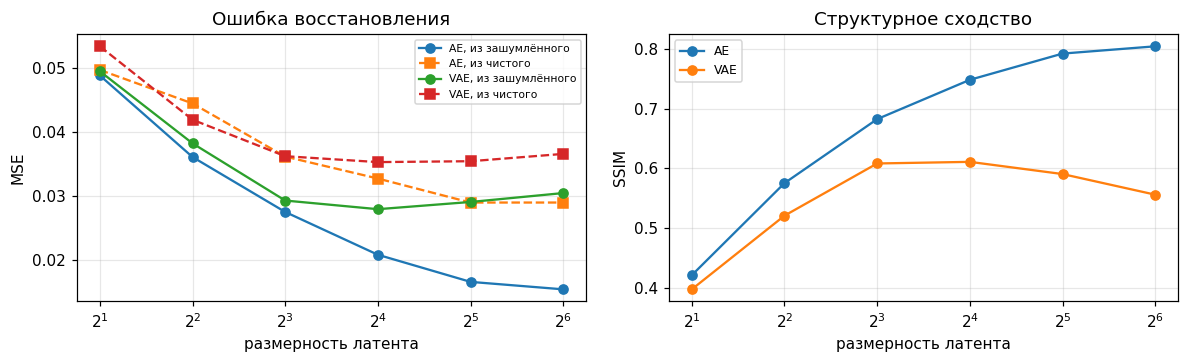

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for m in ['AE', 'VAE']:
    s = lat[lat.model == m].sort_values('latent')
    axes[0].plot(s.latent, s.mse_noisy, marker='o', label=f'{m}, из зашумлённого')
    axes[0].plot(s.latent, s.mse_clean, marker='s', ls='--', label=f'{m}, из чистого')
    axes[1].plot(s.latent, s.ssim_noisy, marker='o', label=m)
axes[0].set_xscale('log', base=2); axes[0].set_xlabel('размерность латента')
axes[0].set_ylabel('MSE'); axes[0].set_title('Ошибка восстановления')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7)
axes[1].set_xscale('log', base=2); axes[1].set_xlabel('размерность латента')
axes[1].set_ylabel('SSIM'); axes[1].set_title('Структурное сходство')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Тип и уровень зашумления

In [9]:
LATENT = int(lat[lat.model == 'AE'].sort_values('mse_noisy').iloc[0]['latent'])
print(f'выбрана размерность латента {LATENT}')

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for nname, nf in NOISES.items():
        for level in [0.2, 0.4]:
            Xn_tr = nf(Xtr, level, np.random.default_rng(20260905))
            Xn_val = nf(Xval, level, np.random.default_rng(1))
            torch.manual_seed(20260905)
            model = cls(latent=LATENT, hidden=(256,))
            train_ae(model, Xn_tr, Xtr, epochs=EPOCHS, lr=1e-3)
            mse_n, ssim_n = quality(Xval, reconstruct(model, Xn_val))
            mse_c, ssim_c = quality(Xval, reconstruct(model, Xval))
            mse_in, ssim_in = quality(Xval, Xn_val)  # качество самого зашумлённого входа
            rows.append(dict(stage='шум', dataset='MNIST', model=cls_name,
                             latent=LATENT, hidden='(256,)', noise=nname,
                             level=level, epochs=EPOCHS, lr=1e-3,
                             mse_noisy=mse_n, ssim_noisy=ssim_n,
                             mse_clean=mse_c, ssim_clean=ssim_c,
                             mse_input=mse_in, ssim_input=ssim_in,
                             params=sum(p.numel() for p in model.parameters())))
noi = pd.DataFrame(rows)
noi['выигрыш SSIM'] = noi.ssim_noisy - noi.ssim_input
print(noi[['model', 'noise', 'level', 'ssim_input', 'ssim_noisy', 'выигрыш SSIM',
           'mse_input', 'mse_noisy']].round(4).to_string(index=False))

выбрана размерность латента 64


model       noise  level  ssim_input  ssim_noisy  выигрыш SSIM  mse_input  mse_noisy
   AE равномерный    0.2      0.6761      0.8610        0.1849     0.0073     0.0110
   AE равномерный    0.4      0.5774      0.8288        0.2514     0.0284     0.0135
   AE  нормальный    0.2      0.6095      0.8374        0.2280     0.0211     0.0128
   AE  нормальный    0.4      0.4436      0.7652        0.3216     0.0794     0.0185
   AE       пятна    0.2      0.8094      0.7783       -0.0310     0.0274     0.0172
   AE       пятна    0.4      0.5350      0.5880        0.0530     0.0824     0.0347
  VAE равномерный    0.2      0.6761      0.5917       -0.0844     0.0073     0.0260
  VAE равномерный    0.4      0.5774      0.5631       -0.0143     0.0284     0.0288
  VAE  нормальный    0.2      0.6095      0.5745       -0.0350     0.0211     0.0278
  VAE  нормальный    0.4      0.4436      0.5143        0.0708     0.0794     0.0333
  VAE       пятна    0.2      0.8094      0.5317       -0.2777   

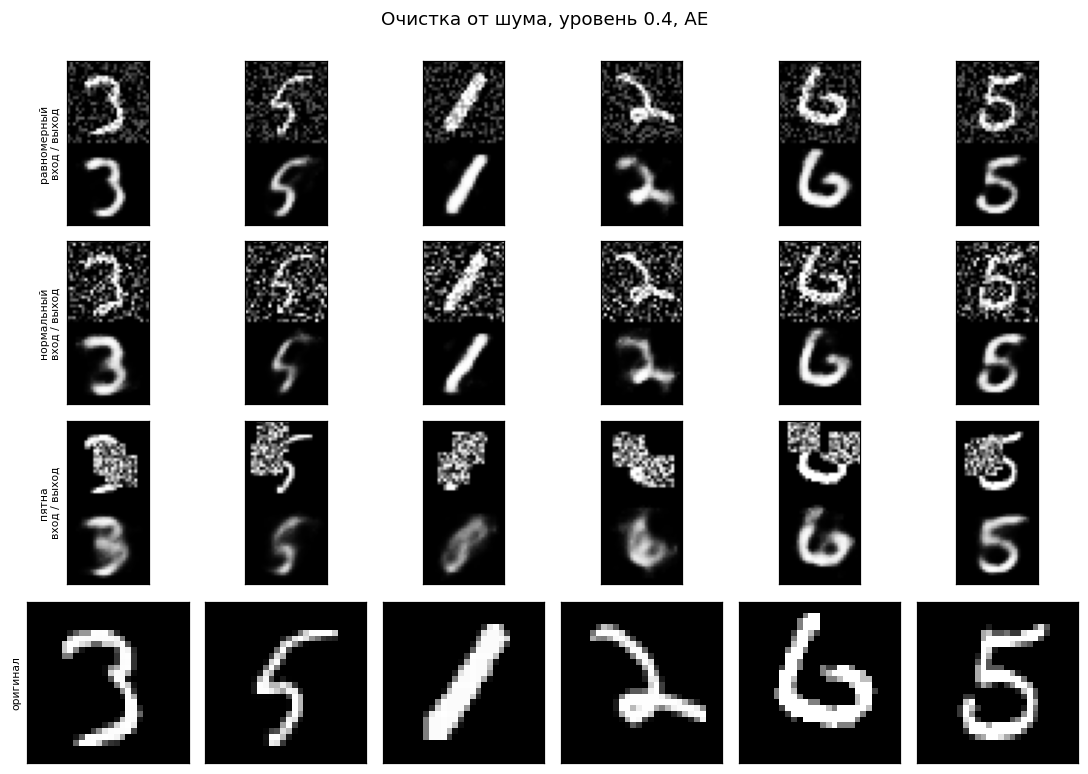

In [10]:
fig, axes = plt.subplots(4, 6, figsize=(10, 7))
for row, (nname, nf) in enumerate(NOISES.items()):
    Xn_tr = nf(Xtr, 0.4, np.random.default_rng(20260905))
    Xn_val = nf(Xval, 0.4, np.random.default_rng(1))
    torch.manual_seed(20260905)
    model = AE(latent=LATENT, hidden=(256,))
    train_ae(model, Xn_tr, Xtr, epochs=EPOCHS, lr=1e-3)
    rec = reconstruct(model, Xn_val)
    for col in range(6):
        # vstack ставит вход над выходом, получается две строки в одной картинке
        axes[row, col].imshow(np.vstack([Xn_val[col], rec[col]]), cmap='gray')
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f'{nname}\nвход / выход', fontsize=7)
for col in range(6):
    axes[3, col].imshow(Xval[col], cmap='gray')
    axes[3, col].set_xticks([]); axes[3, col].set_yticks([])
axes[3, 0].set_ylabel('оригинал', fontsize=7)
fig.suptitle('Очистка от шума, уровень 0.4, AE', y=1.0)
plt.tight_layout()
plt.show()

## 6. Архитектура кодера, число эпох и коэффициент обучения

In [11]:
HIDDENS = [(128,), (256,), (512, 256), (512, 256, 128)]
HIDDEN_BY_NAME = {str(h): h for h in HIDDENS}  # чтобы вернуть кортеж по строке из таблицы

rows = []
for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
    for hidden in HIDDENS:
        torch.manual_seed(20260905)
        model = cls(latent=LATENT, hidden=hidden)
        train_ae(model, Xtr_n, Xtr, epochs=EPOCHS, lr=1e-3)
        mse_n, ssim_n = quality(Xval, reconstruct(model, Xval_n))
        mse_c, ssim_c = quality(Xval, reconstruct(model, Xval))
        rows.append(dict(stage='архитектура', dataset='MNIST', model=cls_name,
                         latent=LATENT, hidden=str(hidden), noise='нормальный',
                         level=LEVEL, epochs=EPOCHS, lr=1e-3,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters())))
arch = pd.DataFrame(rows)
print(arch[['model', 'hidden', 'mse_noisy', 'ssim_noisy', 'params']].round(4).to_string(index=False))

HIDDEN = HIDDEN_BY_NAME[arch[arch.model == 'AE'].sort_values('mse_noisy').iloc[0]['hidden']]
print(f'\nвыбраны слои кодера {HIDDEN}')

model          hidden  mse_noisy  ssim_noisy  params
   AE          (128,)     0.0203      0.7472  218192
   AE          (256,)     0.0154      0.8045  435536
   AE      (512, 256)     0.0205      0.7670 1100112
   AE (512, 256, 128)     0.0271      0.7006 1149520
  VAE          (128,)     0.0362      0.4871  226448
  VAE          (256,)     0.0304      0.5560  451984
  VAE      (512, 256)     0.0408      0.5147 1116560
  VAE (512, 256, 128)     0.0498      0.3929 1157776

выбраны слои кодера (256,)


In [12]:
rows = []
for lr in [3e-4, 1e-3, 3e-3]:
    for epochs in [10, 20, 40]:
        torch.manual_seed(20260905)
        model = AE(latent=LATENT, hidden=HIDDEN)
        train_ae(model, Xtr_n, Xtr, epochs=epochs, lr=lr)
        mse_n, ssim_n = quality(Xval, reconstruct(model, Xval_n))
        rows.append(dict(stage='обучение', dataset='MNIST', model='AE',
                         latent=LATENT, hidden=str(HIDDEN), noise='нормальный',
                         level=LEVEL, epochs=epochs, lr=lr,
                         mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=np.nan, ssim_clean=np.nan,
                         params=sum(p.numel() for p in model.parameters())))
sched = pd.DataFrame(rows)
print('MSE восстановления зашумлённых:')
print(sched.pivot_table(index='lr', columns='epochs', values='mse_noisy').round(4).to_string())
print('\nSSIM восстановления зашумлённых:')
print(sched.pivot_table(index='lr', columns='epochs', values='ssim_noisy').round(4).to_string())

best_sched = sched.sort_values('mse_noisy').iloc[0]
LR, EP = float(best_sched['lr']), int(best_sched['epochs'])
print(f'\nвыбраны lr {LR}, эпох {EP}')

MSE восстановления зашумлённых:
epochs      10      20      40
lr                            
0.0003  0.0323  0.0230  0.0164
0.0010  0.0208  0.0154  0.0126
0.0030  0.0159  0.0134  0.0125

SSIM восстановления зашумлённых:
epochs      10      20      40
lr                            
0.0003  0.5763  0.7022  0.7875
0.0010  0.7330  0.8045  0.8397
0.0030  0.8098  0.8368  0.8520

выбраны lr 0.003, эпох 40


## 7. Обе выборки и генерация из латентного пространства

In [13]:
rows = []
models_final = {}
for ds in ['MNIST', 'FashionMNIST']:
    Xa, _, Xb, _ = DATA[ds]
    Xa_n = noise_normal(Xa, LEVEL, np.random.default_rng(20260905))
    Xb_n = noise_normal(Xb, LEVEL, np.random.default_rng(1))
    for cls_name, cls in [('AE', AE), ('VAE', VAE)]:
        torch.manual_seed(20260905)
        model = cls(latent=LATENT, hidden=HIDDEN)
        train_ae(model, Xa_n, Xa, epochs=EP, lr=LR)
        mse_n, ssim_n = quality(Xb, reconstruct(model, Xb_n))
        mse_c, ssim_c = quality(Xb, reconstruct(model, Xb))
        models_final[(ds, cls_name)] = model
        rows.append(dict(stage='финал', dataset=ds, model=cls_name, latent=LATENT,
                         hidden=str(HIDDEN), noise='нормальный', level=LEVEL,
                         epochs=EP, lr=LR, mse_noisy=mse_n, ssim_noisy=ssim_n,
                         mse_clean=mse_c, ssim_clean=ssim_c,
                         params=sum(p.numel() for p in model.parameters())))
final = pd.DataFrame(rows)
print('качество восстановления на тестовой выборке:')
print(final[['dataset', 'model', 'mse_clean', 'ssim_clean', 'mse_noisy', 'ssim_noisy']]
      .round(4).to_string(index=False))

качество восстановления на тестовой выборке:
     dataset model  mse_clean  ssim_clean  mse_noisy  ssim_noisy
       MNIST    AE     0.0136      0.8523     0.0124      0.8541
       MNIST   VAE     0.0313      0.6701     0.0258      0.6666
FashionMNIST    AE     0.0209      0.7160     0.0141      0.6975
FashionMNIST   VAE     0.0280      0.5666     0.0230      0.5700


In [14]:
allres = pd.concat([lat, noi.drop(columns=['выигрыш SSIM', 'mse_input', 'ssim_input']),
                    arch, sched, final], ignore_index=True)
allres.to_csv('results.csv', index=False)

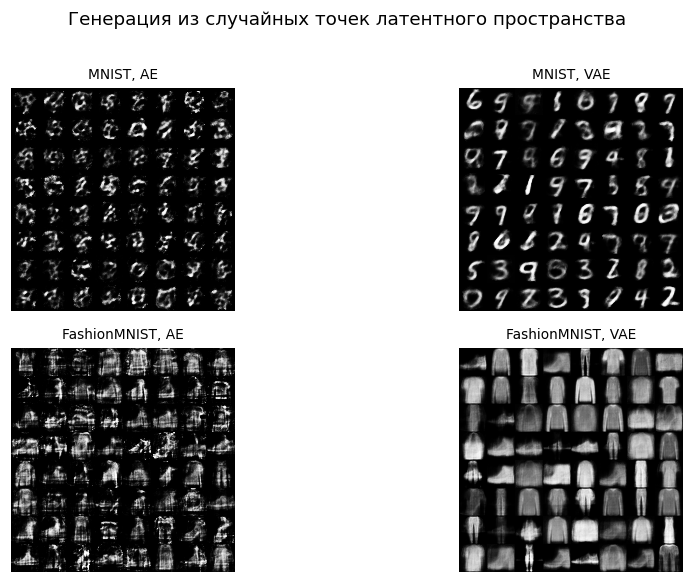

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.2))
for i, ds in enumerate(['MNIST', 'FashionMNIST']):
    for j, m in enumerate(['AE', 'VAE']):
        model = models_final[(ds, m)]
        model.eval()
        with torch.no_grad():
            imgs = model.sample(64).cpu().numpy().reshape(-1, 28, 28)
        # 64 изображения выкладываются в таблицу 8 на 8
        canvas = np.vstack([np.hstack([imgs[r * 8 + c] for c in range(8)])
                            for r in range(8)])
        axes[i, j].imshow(canvas, cmap='gray')
        axes[i, j].set_title(f'{ds}, {m}', fontsize=9)
        axes[i, j].axis('off')
fig.suptitle('Генерация из случайных точек латентного пространства', y=1.01)
plt.tight_layout()
plt.show()

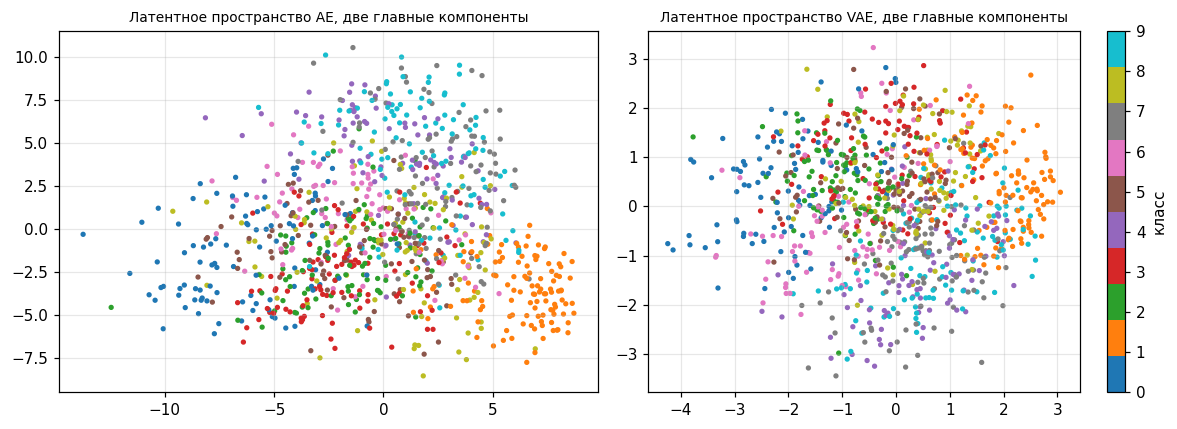

стандартное отклонение координат кода, среднее по координатам:
  AE:                        1.573
  VAE, z = mu + sigma * eps: 1.028 (у N(0, 1) было бы 1.000)


In [16]:
model = models_final[('MNIST', 'VAE')]
Xb, yb = DATA['MNIST'][2], DATA['MNIST'][3]
model.eval()
with torch.no_grad():
    x = torch.tensor(Xb.reshape(len(Xb), -1)).to(DEVICE)
    h = model.encoder(x)
    mu, logvar = model.mu(h), model.logvar(h)
    z_vae = mu.cpu().numpy()
    # код с шумом, как при обучении: именно его разброс сравнивается с N(0, 1)
    z_vae_s = (mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)).cpu().numpy()
    z_ae = models_final[('MNIST', 'AE')].encoder(x).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (z, name) in zip(axes, [(z_ae, 'AE'), (z_vae, 'VAE')]):
    p = PCA(2).fit_transform(z)  # латент сжимается до двух координат ради картинки
    sc = ax.scatter(p[:, 0], p[:, 1], c=yb, cmap='tab10', s=6)
    ax.set_title(f'Латентное пространство {name}, две главные компоненты', fontsize=9)
    ax.grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='класс')
plt.tight_layout()
plt.show()

print('стандартное отклонение координат кода, среднее по координатам:')
print(f'  AE:                        {z_ae.std(0).mean():.3f}')
print(f'  VAE, z = mu + sigma * eps: {z_vae_s.std(0).mean():.3f} (у N(0, 1) было бы 1.000)')